In [2]:
from pathlib import Path
import re

import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from pathlib import Path

archive_dir = Path.cwd().parent / "data/processed/archive"
files = sorted(archive_dir.glob("*.h5ad"))

files

[WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/paul15_res_0.5.h5ad'),
 WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/paul15_res_1.0.h5ad'),
 WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/paul15_res_1.5.h5ad'),
 WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/paul15_res_2.0.h5ad'),
 WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/paul15_res_2.5.h5ad'),
 WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/pbmc3k_res_0.5.h5ad'),
 WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/pbmc3k_res_1.0.h5ad'),
 WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/pbmc3k_res_1.5.h5ad'),
 WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/pbmc3k_res_2.0.h5ad'),
 WindowsPath('d:/personal_projects/scRNAseq_lightGBM/data/processed/archive/pbmc3k_res_2.5.h5ad'),
 WindowsPa

In [5]:
def parse_name(path):
    stem = path.stem  # e.g. pbmc3k_res_1.5
    m = re.match(r"(.+)_res_([0-9.]+)", stem)
    if m is None:
        raise ValueError(f"Unexpected filename: {stem}")
    dataset = m.group(1)
    resolution = float(m.group(2))
    return dataset, resolution

records = []
for f in files:
    dataset, resolution = parse_name(f)
    records.append({
        "path": f,
        "dataset": dataset,
        "resolution": resolution,
    })

runs_df = pd.DataFrame(records).sort_values(["dataset", "resolution"]).reset_index(drop=True)
runs_df

,path,dataset,resolution
0,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,0.5
1,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,1.0
2,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,1.5
3,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,2.0
4,d:\personal_projects\scRNAseq_lightGBM\data\pr...,paul15,2.5
5,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,0.5
6,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,1.0
7,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,1.5
8,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,2.0
9,d:\personal_projects\scRNAseq_lightGBM\data\pr...,pbmc3k,2.5


In [8]:
def add_normalized_entropy(adata, label_key="leiden", entropy_key="entropy_lgbm"):
    n_classes = adata.obs[label_key].astype(str).nunique()
    adata.obs["entropy_norm_lgbm"] = adata.obs[entropy_key] / np.log(n_classes)
    return adata

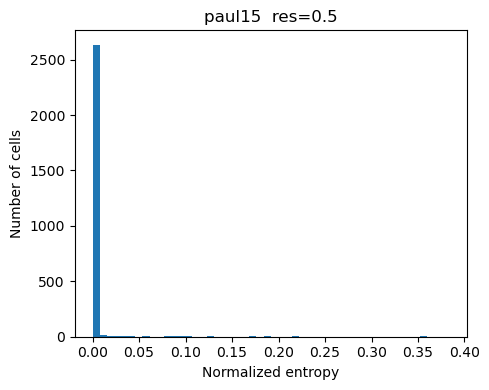

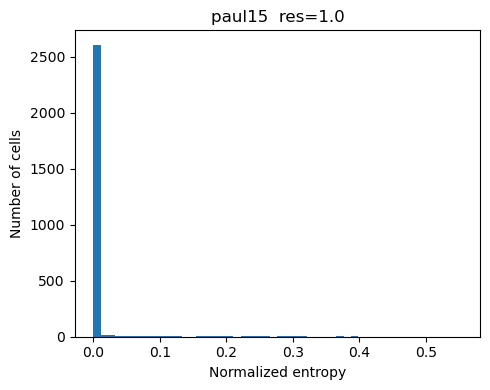

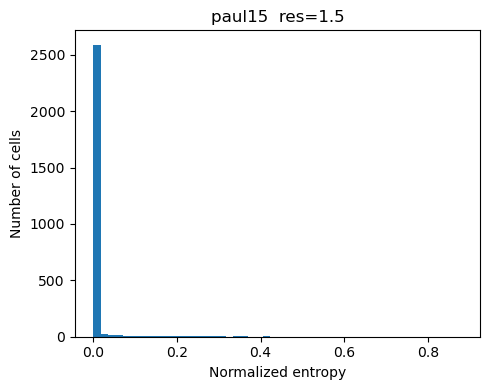

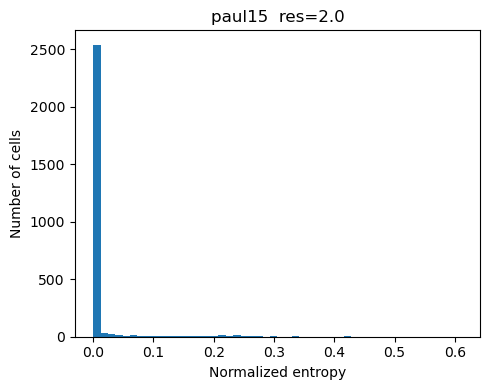

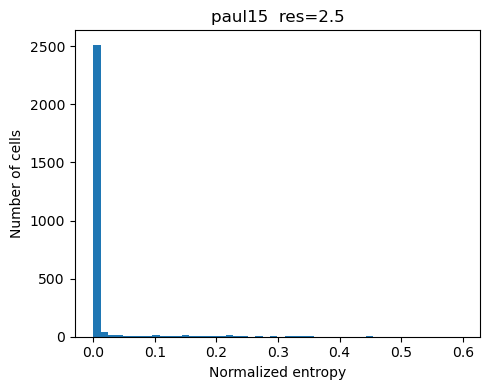

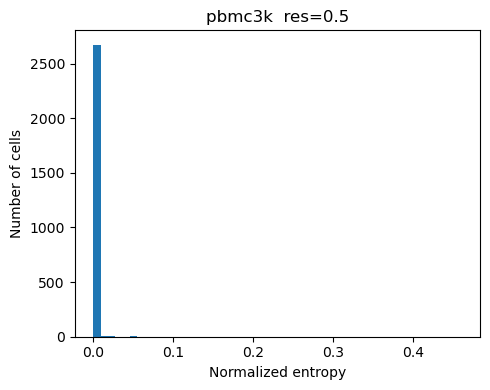

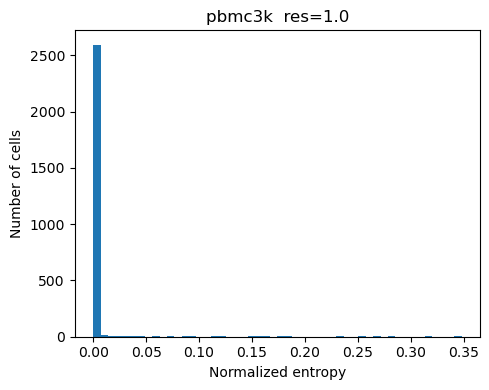

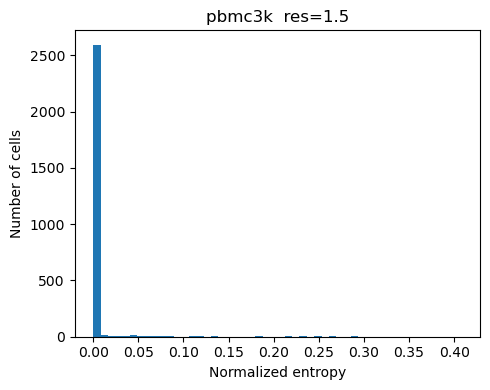

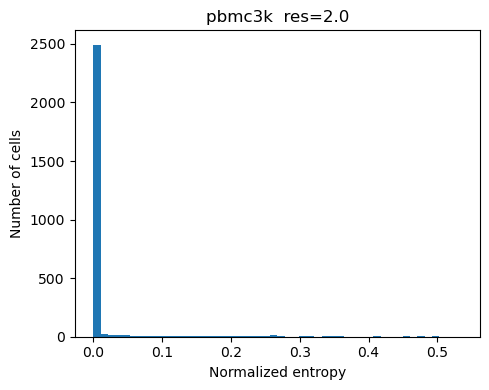

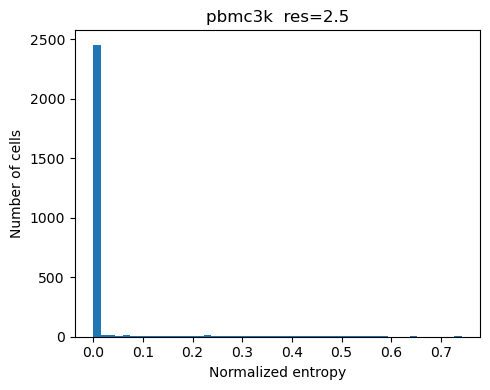

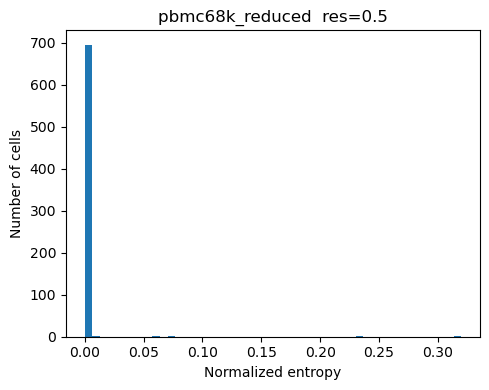

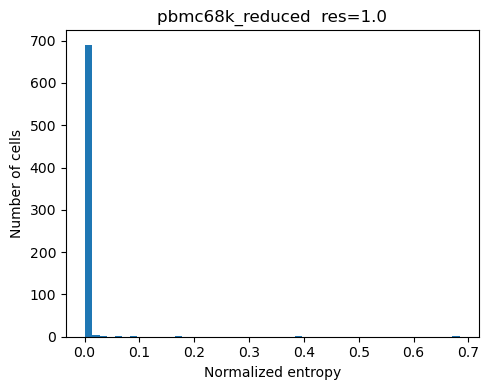

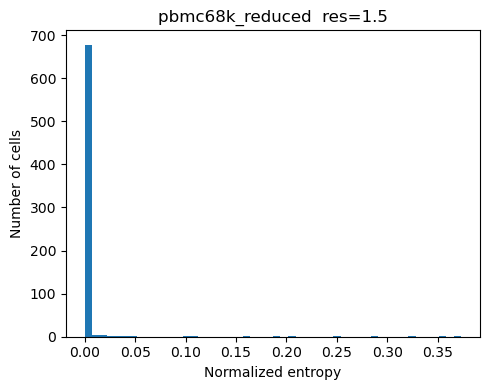

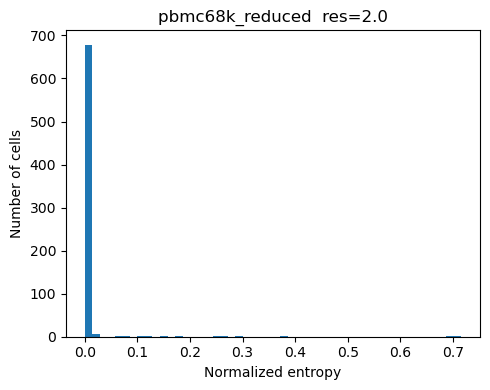

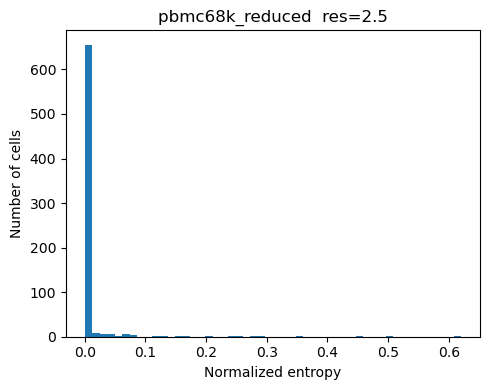

In [9]:
for _, row in runs_df.iterrows():
    adata = sc.read_h5ad(row["path"])
    adata = add_normalized_entropy(adata)

    plt.figure(figsize=(5, 4))
    plt.hist(adata.obs["entropy_norm_lgbm"].dropna(), bins=50)
    plt.title(f"{row['dataset']}  res={row['resolution']}")
    plt.xlabel("Normalized entropy")
    plt.ylabel("Number of cells")
    plt.tight_layout()
    plt.show()

In [10]:
percentiles = [50, 75, 90, 95, 99]

rows = []

for _, row in runs_df.iterrows():
    adata = sc.read_h5ad(row["path"])
    adata = add_normalized_entropy(adata)

    vals = adata.obs["entropy_norm_lgbm"].values

    row_dict = {
        "dataset": row["dataset"],
        "resolution": row["resolution"],
    }

    for p in percentiles:
        row_dict[f"p{p}"] = np.percentile(vals, p)

    rows.append(row_dict)

percentile_df = pd.DataFrame(rows).sort_values(["dataset", "resolution"])
percentile_df

,dataset,resolution,p50,p75,p90,p95,p99
0,paul15,0.5,0.000018,0.000126,0.000355,0.001075,0.172449
1,paul15,1.0,0.000049,0.000182,0.000377,0.006472,0.258947
2,paul15,1.5,0.000078,0.000193,0.000632,0.020000,0.238022
3,paul15,2.0,0.000089,0.000183,0.001956,0.041990,0.250622
4,paul15,2.5,0.000095,0.000193,0.003264,0.067714,0.246906
5,pbmc3k,0.5,0.000005,0.000018,0.000117,0.000256,0.012848
6,pbmc3k,1.0,0.000023,0.000146,0.000378,0.001500,0.148459
7,pbmc3k,1.5,0.000039,0.000166,0.000374,0.003412,0.170997
8,pbmc3k,2.0,0.000094,0.000214,0.001359,0.065407,0.331818
9,pbmc3k,2.5,0.000093,0.000190,0.004031,0.223652,0.520543


In [6]:
adata = sc.read_h5ad(runs_df.loc[0, "path"])

adata.obsm.keys()

KeysView(AxisArrays with keys: X_pca, X_umap)

In [8]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

project_root = Path.cwd().parent
metrics_dir = project_root / "artifacts/metrics/archive"

metric_files = sorted(metrics_dir.glob("*.json"))
len(metric_files), metric_files[:5]

records = []

for path in metric_files:
    with open(path, "r", encoding="utf-8") as f:
        d = json.load(f)
    d["metrics_file"] = path.name
    records.append(d)

metrics_df = pd.DataFrame(records)
metrics_df.head()

cols = [
    "dataset_name",
    "leiden_resolution",
    "n_clusters",
    "cv_repeats",
    "cv_accuracy_mean",
    "cv_accuracy_std",
    "cv_macro_f1_mean",
    "cv_macro_f1_std",
    "cv_mean_confidence_test_mean",
    "cv_mean_confidence_test_std",
    "cv_low_confidence_fraction_test_mean",
    "cv_low_confidence_fraction_test_std",
    "cv_mean_entropy_norm_mean",
    "cv_mean_entropy_norm_std",
    "cv_mean_margin_mean",
    "cv_mean_margin_std",
    "mean_entropy_norm_all_cells",
    "p95_entropy_norm_all_cells",
    "p99_entropy_norm_all_cells",
    "mean_margin_all_cells",
    "p05_margin_all_cells",
    "mean_confidence_all_cells",
    "low_confidence_fraction_all_cells",
]

summary_df = (
    metrics_df[cols]
    .sort_values(["dataset_name", "leiden_resolution"])
    .reset_index(drop=True)
)

summary_df

,dataset_name,leiden_resolution,n_clusters,cv_repeats,cv_accuracy_mean,cv_accuracy_std,cv_macro_f1_mean,cv_macro_f1_std,cv_mean_confidence_test_mean,cv_mean_confidence_test_std,...,cv_mean_entropy_norm_std,cv_mean_margin_mean,cv_mean_margin_std,mean_entropy_norm_all_cells,p95_entropy_norm_all_cells,p99_entropy_norm_all_cells,mean_margin_all_cells,p05_margin_all_cells,mean_confidence_all_cells,low_confidence_fraction_all_cells
0,paul15,0.5,7,3,0.947741,0.008716,0.947649,0.012588,0.983134,0.003512,...,0.003588,0.966811,0.006966,0.004370,0.001075,0.172449,0.993423,0.999616,0.996690,0.002564
1,paul15,1.0,10,3,0.903297,0.006661,0.901994,0.013038,0.969968,0.004451,...,0.003832,0.941974,0.008510,0.007118,0.006472,0.258947,0.987693,0.996208,0.993463,0.004762
2,paul15,1.5,14,3,0.875092,0.016011,0.862615,0.020671,0.957867,0.004163,...,0.003385,0.920920,0.007596,0.008322,0.020000,0.238022,0.985257,0.983900,0.991947,0.005128
3,paul15,2.0,18,3,0.846520,0.015472,0.840567,0.016063,0.944368,0.004355,...,0.003854,0.897897,0.007919,0.009830,0.041990,0.250622,0.981782,0.961190,0.989958,0.005861
4,paul15,2.5,21,3,0.834310,0.013000,0.819384,0.016418,0.940126,0.004475,...,0.003442,0.891634,0.007993,0.010970,0.067714,0.246906,0.978791,0.922026,0.988205,0.008059
5,pbmc3k,0.5,8,3,0.973086,0.005928,0.946033,0.022068,0.992075,0.002035,...,0.002100,0.985146,0.003797,0.001629,0.000256,0.012848,0.997303,0.999914,0.998600,0.001481
6,pbmc3k,1.0,9,3,0.927654,0.010829,0.920543,0.023418,0.979853,0.002756,...,0.002708,0.961205,0.005401,0.003876,0.001500,0.148459,0.994268,0.999302,0.997066,0.001111
7,pbmc3k,1.5,11,3,0.913704,0.010983,0.921167,0.014740,0.972574,0.004298,...,0.003497,0.947580,0.008231,0.004463,0.003412,0.170997,0.992445,0.998316,0.996093,0.002222
8,pbmc3k,2.0,15,3,0.815185,0.017096,0.762856,0.022025,0.934404,0.004708,...,0.003885,0.886200,0.007581,0.013233,0.065407,0.331818,0.977320,0.933025,0.987144,0.009630
9,pbmc3k,2.5,23,3,0.752469,0.012717,0.632551,0.023041,0.877921,0.006839,...,0.006136,0.808908,0.010243,0.024913,0.223652,0.520543,0.957171,0.606405,0.972876,0.032593
